In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("spotify dataset.csv")
print(df.head())
print(df.shape)
print(df.info())
print(df.isnull().sum())

                 track_id                                         track_name  \
0  6f807x0ima9a1j3VPbc7VN  I Don't Care (with Justin Bieber) - Loud Luxur...   
1  0r7CVbZTWZgbTCYdfa2P31                    Memories - Dillon Francis Remix   
2  1z1Hg7Vb0AhHDiEmnDE79l                    All the Time - Don Diablo Remix   
3  75FpbthrwQmzHlBJLuGdC7                  Call You Mine - Keanu Silva Remix   
4  1e8PAfcKUYoKkxPhrHqw4x            Someone You Loved - Future Humans Remix   

       track_artist  track_popularity          track_album_id  \
0        Ed Sheeran                66  2oCs0DGTsRO98Gh5ZSl2Cx   
1          Maroon 5                67  63rPSO264uRjW1X5E6cWv6   
2      Zara Larsson                70  1HoSmj2eLcsrR0vE9gThr4   
3  The Chainsmokers                60  1nqYsOef1yKKuGOVchbsk6   
4     Lewis Capaldi                69  7m7vv9wlQ4i0LFuJiE2zsQ   

                                    track_album_name track_album_release_date  \
0  I Don't Care (with Justin Bieber) [Loud Luxu

In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df.dropna(inplace=True)

In [7]:
print(df.isnull().sum())

track_id                    0
track_name                  0
track_artist                0
track_popularity            0
track_album_id              0
track_album_name            0
track_album_release_date    0
playlist_name               0
playlist_id                 0
playlist_genre              0
playlist_subgenre           0
danceability                0
energy                      0
key                         0
loudness                    0
mode                        0
speechiness                 0
acousticness                0
instrumentalness            0
liveness                    0
valence                     0
tempo                       0
duration_ms                 0
dtype: int64


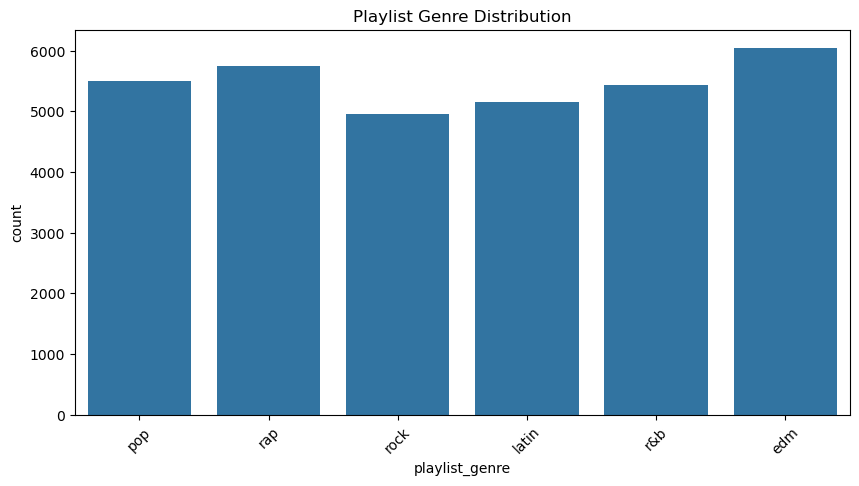

In [8]:
plt.figure(figsize=(10,5))
sns.countplot(x='playlist_genre', data=df)
plt.xticks(rotation=45)
plt.title("Playlist Genre Distribution")
plt.show()

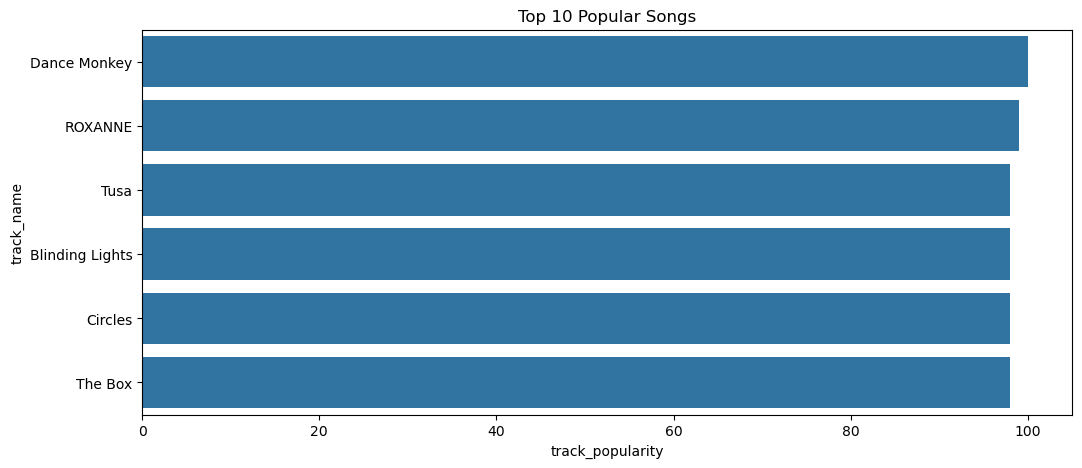

In [9]:
top_songs = df.sort_values(
    by='track_popularity',
    ascending=False
).head(10)

plt.figure(figsize=(12,5))

sns.barplot(
    x='track_popularity',
    y='track_name',
    data=top_songs
)

plt.title("Top 10 Popular Songs")

plt.show()

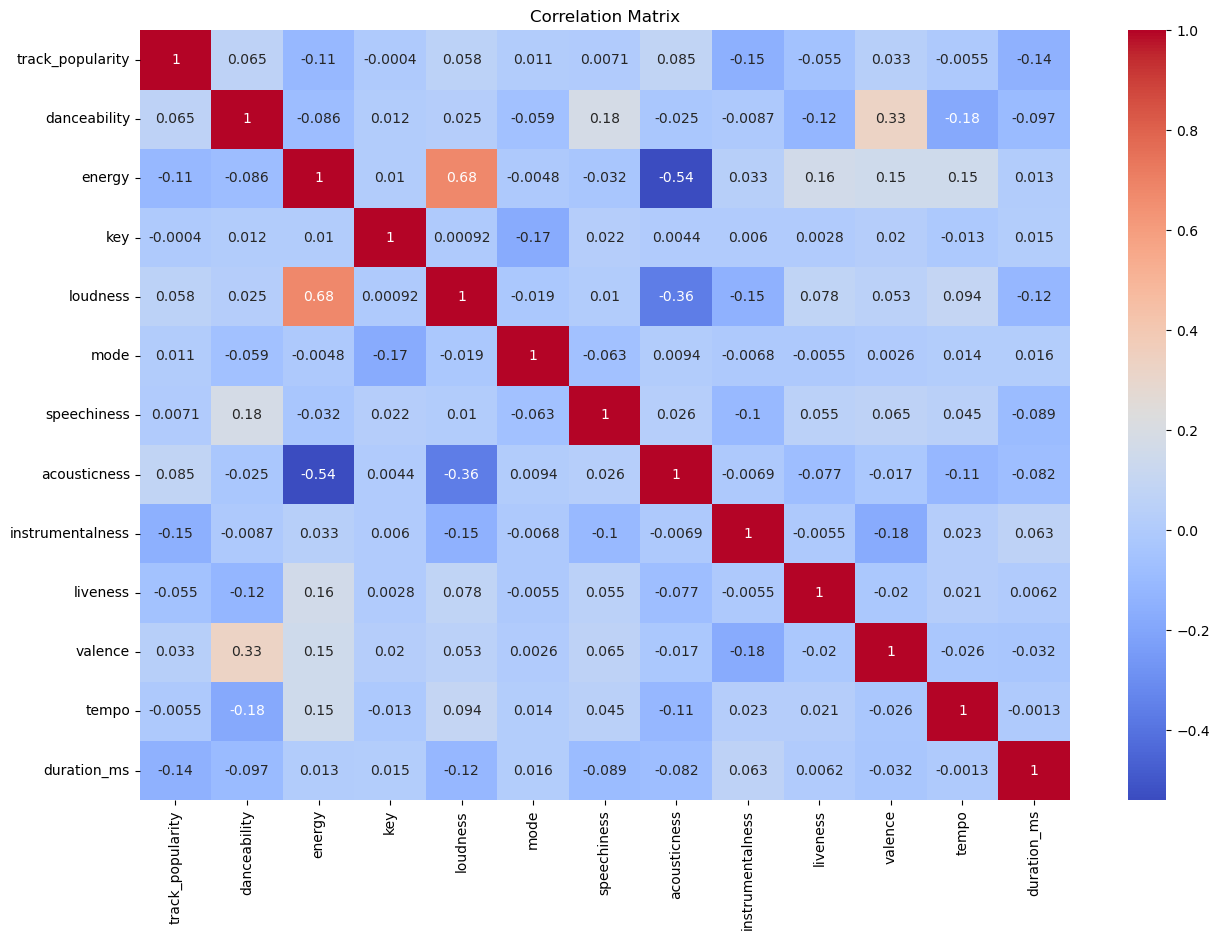

In [11]:
num_data = df.select_dtypes(include=['int64','float64'])
corr = num_data.corr()
plt.figure(figsize=(15,10))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Matrix")
plt.show()

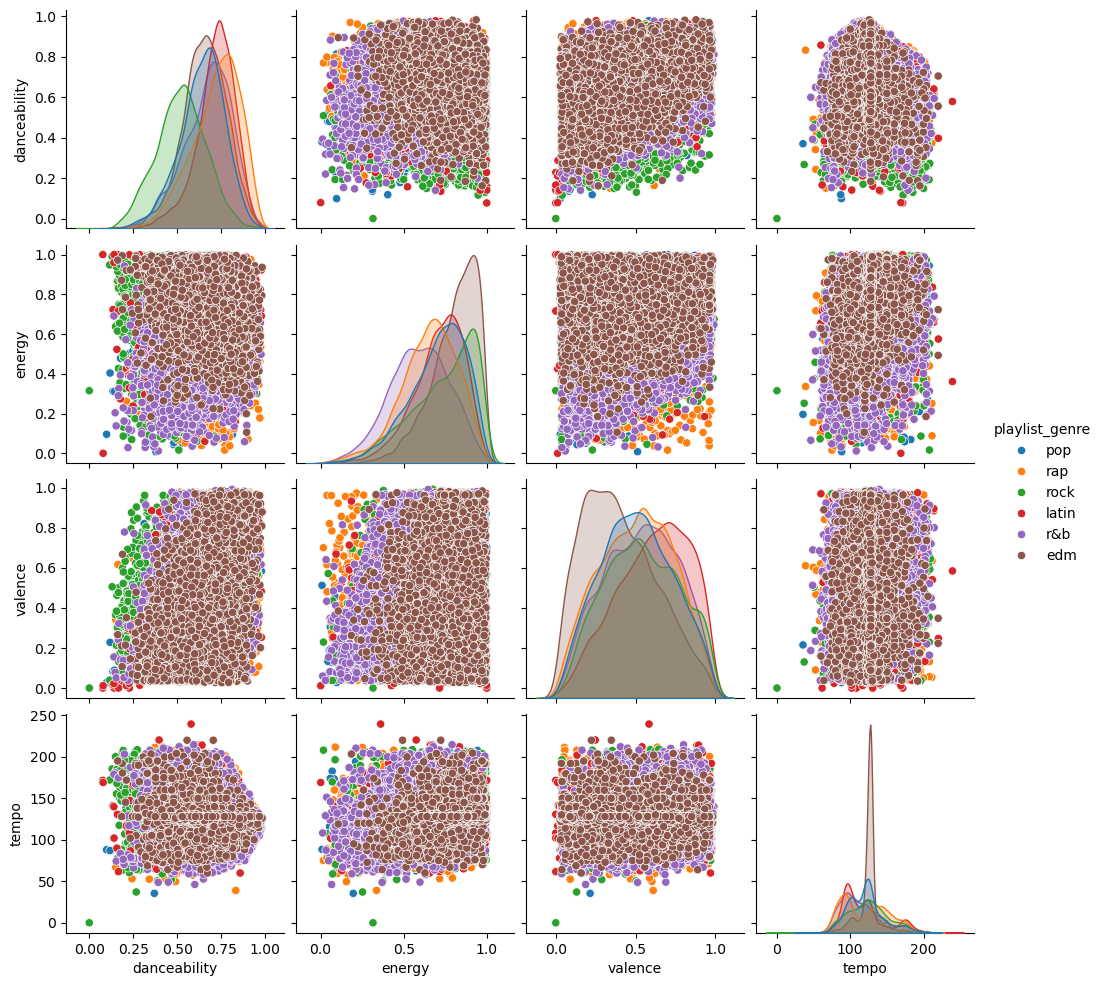

In [15]:
features = [
    'danceability',
    'energy',
    'valence',
    'tempo',
    'playlist_genre'
]
sns.pairplot(
    df[features],
    hue='playlist_genre'
)
plt.show()

In [16]:
X = df[[
    'danceability',
    'energy',
    'valence',
    'tempo',
    'acousticness',
    'speechiness'
]]

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [19]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

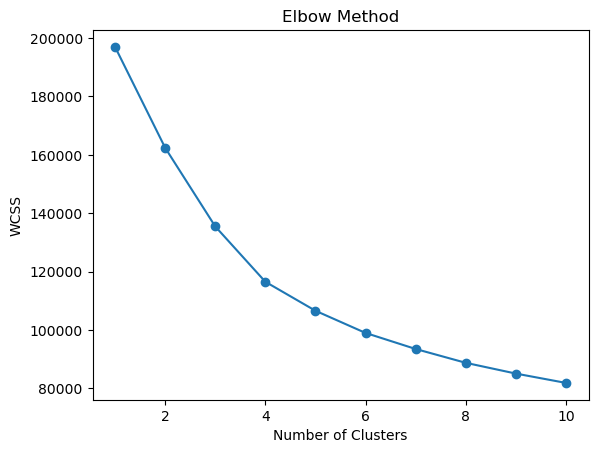

In [20]:
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [22]:
kmeans = KMeans(
    n_clusters=6,
    random_state=42
)
df['Cluster'] = kmeans.fit_predict(X_scaled)

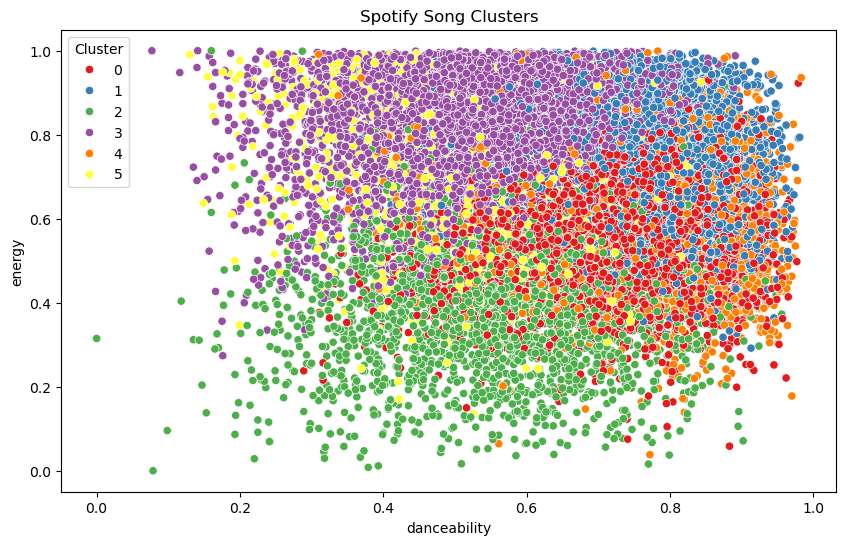

In [23]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='danceability',
    y='energy',
    hue='Cluster',
    data=df,
    palette='Set1'
)
plt.title("Spotify Song Clusters")
plt.show()

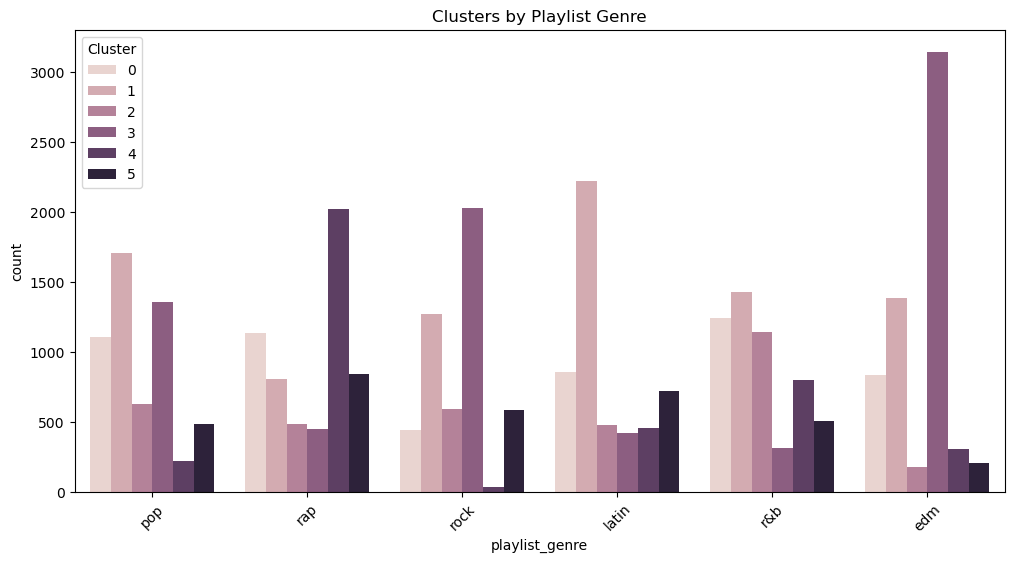

In [25]:
plt.figure(figsize=(12,6))
sns.countplot(
    x='playlist_genre',
    hue='Cluster',
    data=df
)
plt.xticks(rotation=45)
plt.title("Clusters by Playlist Genre")
plt.show()

/home/user/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


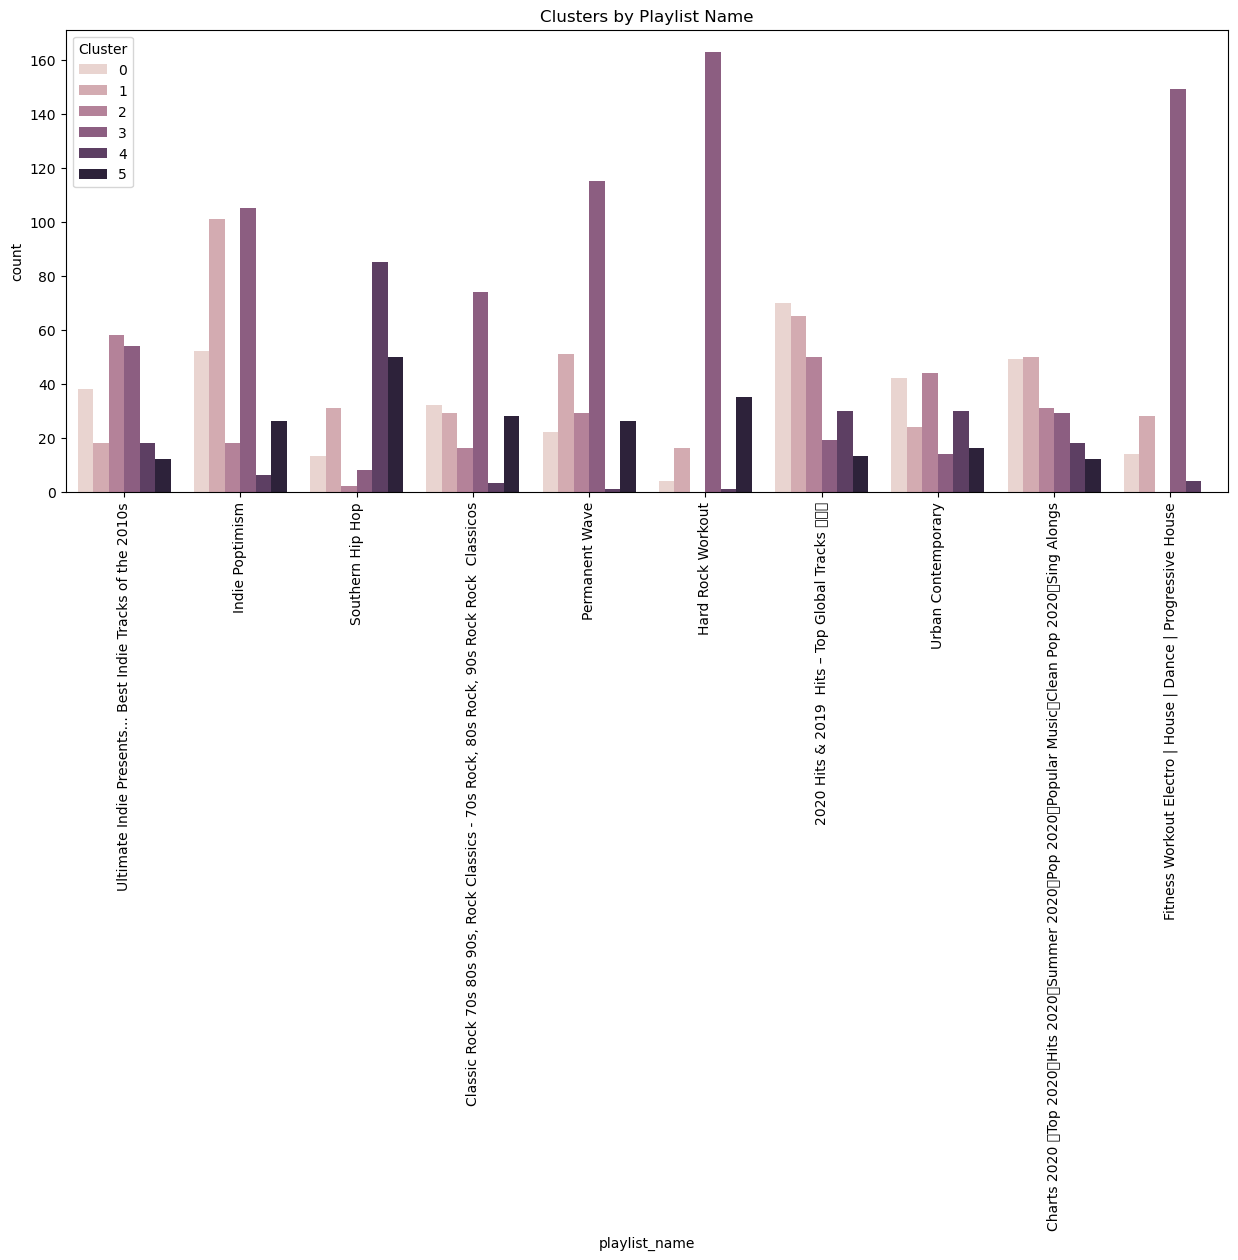

In [26]:
top_playlists = df['playlist_name'].value_counts().head(10).index
temp = df[df['playlist_name'].isin(top_playlists)]
plt.figure(figsize=(15,6))
sns.countplot(
    x='playlist_name',
    hue='Cluster',
    data=temp
)
plt.xticks(rotation=90)
plt.title("Clusters by Playlist Name")
plt.show()

In [28]:
def recommend_songs(song_name):
    cluster = df[df['track_name'] == song_name]['Cluster'].values[0]
    recommendations = df[
        df['Cluster'] == cluster
    ][['track_name','track_artist']].head(10)
    return recommendations

In [29]:
print(recommend_songs("I Don't Care"))

                                           track_name      track_artist
18  Dancing With A Stranger (With Normani) - Cheat...         Sam Smith
41                                        Higher Love              Kygo
57                                          Cool Kids           Olympis
70                                      Call You Mine  The Chainsmokers
72                                       Here With Me        Marshmello
84                                             Not Ok              Kygo
88  Carry On (from the Original Motion Picture "PO...              Kygo
93                                                SOS            Avicii
95                                         The Middle              Zedd
96                                             Wanted              NOTD
